<center><h1>INF-552 Lab 0</h1></center>
<br>
<center><font size="4">Introduction to Basic Development Tools</font></center>

### Rules

1. Please read the instructions and problem prompts **carefully**.
2. This lab is to give you some basic APIs of numpy, pandas and scikit-learn. Besides, some topics such as how to make your jupyter notebook be a more efficient developing tools, how to use git and GitHub will also be covered. The lab is to be done individually. You may talk to your fellow classmates about general issues ("Remind me again: Which API should I used for doing group by operation to a data set") but about the specifies of how to do these exercises.
3. Along with a similar vein, you can ask the TA for help, but ask questions about **concepts** but not ask the TA to help you debug your code. The TA is here to help, but not to do the work for you.
4. You are welcome to use the class resources and the Internet.
5. Playing with variations. Solve one problems, and then copy the code to a new cell and play around with it. Doing this is the single most important thing when learning programming.
6. This lab will not be graded but the content is highly related to your future programming assignments. So, treat it wisely.
7. All the content having been gone though in the week 1 discussion is just a snapshot of the most basic concepts. **You need to keep study more about Git, GitHub, Pandas, Numpy and Scikit-Learn in order to finish your programming assignments successfully.**
8. Have fun!

### Setup Development Environment

There are many ways to setup the environment. But, I do recommend a simple idea that is using the Anaconda, which is a pre-build python environment with bundles of useful packages.

**To download the Anaconda, go to the following website:
https://www.anaconda.com/distribution/**. Download the correct version based on your operating system and install it step by step.

Then, **configure your PATH environment variable** to make the conda command work. The following command is an easy way to test whether your configuration is correct. If it is, you will see something as like as the sample output.

> **command:**
>
> conda --version
>
> **sample output:**
>
> conda 4.6.12

**Finally, download this jupyter notebook file,** then change the working directory to where its location in terminal, and type the following command to open the jupter notebook and finish the lab.

> **command:** 
> jupyter notebook

In [1]:
import pandas as pd
import numpy as np

### Pandas

#### The read_csv() Method

First, read the documentation about the *read_csv()* method in Pandas (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html). Then, try to read data from file Salaries.csv to a dataframe, make the column playerID in the csv file as the index column and the first row as the header. Also, skip the second row when reading the file.

In [2]:
# Load the dataset: set the first row as header, skip the second row, and use playerID as the index
df = pd.read_csv('Salaries.csv', header=0, skiprows=[1], index_col='playerID')

# Display the first 5 rows to verify the dataframe structure
df.head()

,yearID,teamID,lgID,salary
playerID,,,,
bedrost01,1985,ATL,NL,550000
benedbr01,1985,ATL,NL,545000
campri01,1985,ATL,NL,633333
ceronri01,1985,ATL,NL,625000
chambch01,1985,ATL,NL,800000


#### Indexing and Selecting Data

Select the id of the players who are registered in ATL and HOU and whose salary is higher than one million.

In [3]:
# Define the filtering condition: team must be ATL or HOU, and salary strictly greater than 1 million
condition = ((df['teamID'] == 'ATL') | (df['teamID'] == 'HOU')) & (df['salary'] > 1000000)

# Apply the condition to filter the dataframe
filtered_df = df[condition]

# Extract the player IDs (which we previously set as the index) into a list
high_paid_players_id = filtered_df.index.tolist()

# Output the total count and a quick preview of the results
print(f"Number of players meeting the criteria: {len(high_paid_players_id)}")
print("Player IDs (first 10):", high_paid_players_id[:10], "...")

Number of players meeting the criteria: 595
Player IDs (first 10): ['hornebo01', 'murphda05', 'suttebr01', 'ryanno01', 'hornebo01', 'murphda05', 'suttebr01', 'ryanno01', 'griffke01', 'murphda05'] ...


#### The describe() Method

Calculate the standard Deviation, first quartile, medium, third quartile, mean, maximum, minimum of the salary in team ATL.

In [4]:
# Filter the dataframe for the ATL team, extract the 'salary' column, and generate summary statistics
atl_salary_stats = df[df['teamID'] == 'ATL']['salary'].describe()

# Print the statistical summary
print("ATL Team Salary Statistics:")
print(atl_salary_stats)

ATL Team Salary Statistics:
count    8.850000e+02
mean     2.207749e+06
std      3.434320e+06
min      6.000000e+04
25%      3.000000e+05
50%      6.000000e+05
75%      2.400000e+06
max      1.606180e+07
Name: salary, dtype: float64


#### The iterrows() Method

Create a Python dictionary object whose keys are the headers of the dataframe created in the read_csv() exercise and values are Python list objects that contain data corresponding to the headers. (Here, use the iterrows method to iterate each row of the dataframe and copy it to a dictionary. However, there is a easier way. Learn how the to_dict() method works by yourself later)

In [5]:
# Initialize a dictionary with column headers as keys and empty lists as values
dict_from_df = {header: [] for header in df.columns}

# Iterate through each row and populate the dictionary
for index, row in df.iterrows():
    for header in df.columns:
        dict_from_df[header].append(row[header])

print("Dictionary created successfully! Keys included:", list(dict_from_df.keys()))

Dictionary created successfully! Keys included: ['yearID', 'teamID', 'lgID', 'salary']


#### Create Dataframe Using the Constructor

Read the documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html#pandas.DataFrame and create a dataframe using pd.DataFrame from the dictionary created in the iterrows() exercise. Change the header to "a", "b", "c", ... at creation time.

In [6]:
# Create a new DataFrame using the dictionary created in the previous step
new_df = pd.DataFrame(dict_from_df)

# Rename the column headers to 'a', 'b', 'c', 'd' as required
new_df.columns = ['a', 'b', 'c', 'd']

# Display the first 5 rows to verify the changes
print("New DataFrame with renamed headers:")
print(new_df.head())

New DataFrame with renamed headers:
      a    b   c       d
0  1985  ATL  NL  550000
1  1985  ATL  NL  545000
2  1985  ATL  NL  633333
3  1985  ATL  NL  625000
4  1985  ATL  NL  800000


### Numpy

Quick start: https://www.numpy.org/devdocs/user/quickstart.html

Numpy axes explaination: https://www.sharpsightlabs.com/blog/numpy-axes-explained/

#### The np.array Method

Example 1:

```python
ls = [1, 2, 3]
arr = np.array(ls)
```

Example 2:
```python
>>> np.array([[1, 2], [3, 4]])
array([[1, 2],
       [3, 4]])
```

Now, create a 2-dimensional Python list object, then convert it to a Numpy array object.

In [7]:
# Create a 2-dimensional Python list (e.g., 2 rows and 3 columns)
my_2d_list = [[10, 20, 30], [40, 50, 60]]

# Convert the Python list to a NumPy array
my_arr = np.array(my_2d_list)

# Print the resulting array
print("Successfully converted NumPy Array:\n", my_arr)

Successfully converted NumPy Array:
 [[10 20 30]
 [40 50 60]]


#### ndarray Objects' Attributes

Play with the **ndim, shape, size, dtype, itemsize and data** attribute.

Example:

```python
>>> arr = np.array([[1, 2], [3, 4]])
>>> arr.ndim
2
```

In [8]:
# Print the core attributes of the existing array 'my_arr'
print("1. ndim (Number of dimensions):", my_arr.ndim)
print("2. shape (Array shape / Rows & Columns):", my_arr.shape)
print("3. size (Total number of elements):", my_arr.size)
print("4. dtype (Data type):", my_arr.dtype)
print("5. itemsize (Bytes per element):", my_arr.itemsize)
print("6. data (Memory buffer pointer):", my_arr.data)

1. ndim (Number of dimensions): 2
2. shape (Array shape / Rows & Columns): (2, 3)
3. size (Total number of elements): 6
4. dtype (Data type): int64
5. itemsize (Bytes per element): 8
6. data (Memory buffer pointer): <memory at 0x13849de50>


#### Dimension of ndarray Ojects

Play with the reshape() and flatten() method.

Example:
```python
>>> arr = np.array([[1, 2], [3, 4]])
>>> arr.flatten()
array([1, 2, 3, 4])
```

In [9]:
# The original 'my_arr' is a 2x3 matrix
print("Original Matrix (2x3):\n", my_arr)

# flatten(): Collapses the matrix into a 1-dimensional array
print("\nFlattened Array (1D):", my_arr.flatten())

# reshape(): Changes the shape of the array without changing its data (e.g., to 3 rows and 2 columns)
print("\nReshaped Matrix (3x2):\n", my_arr.reshape(3, 2))

Original Matrix (2x3):
 [[10 20 30]
 [40 50 60]]

Flattened Array (1D): [10 20 30 40 50 60]

Reshaped Matrix (3x2):
 [[10 20]
 [30 40]
 [50 60]]


#### The Slice Operation of ndarray Objects

Understand how the slice operation works for 1-D array and 2-D array.

Example:

```python
>>> arr = np.array([[1, 2, 3], [3, 4, 6], [7, 8, 9]])
>>> arr[1:]
array([[3, 4, 6],
       [7, 8, 9]])
>>> arr[1:, 0:2]
array([[3, 4],
       [7, 8]])
```

In [10]:
# Create a new 3x3 matrix to demonstrate slicing
arr_slice = np.array([[1, 2, 3], 
                      [4, 5, 6], 
                      [7, 8, 9]])
print("Original 3x3 Matrix:\n", arr_slice)

# 1-D Slicing: Extract only the first row (index starts at 0)
print("\nExtracted First Row:", arr_slice[0])

# 2-D Slicing: Extract all rows (using :), and only the first two columns (using 0:2)
print("\nExtracted First Two Columns of All Rows:\n", arr_slice[:, 0:2])

# 2-D Slicing: Extract all rows from the second row onwards, and all columns from the second column onwards
print("\nExtracted Bottom-Right 2x2 Matrix:\n", arr_slice[1:, 1:])

Original 3x3 Matrix:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

Extracted First Row: [1 2 3]

Extracted First Two Columns of All Rows:
 [[1 2]
 [4 5]
 [7 8]]

Extracted Bottom-Right 2x2 Matrix:
 [[5 6]
 [8 9]]


#### The Calculation of ndarray Objects

Play with the **argmin(), argmax(), min(), max(), mean(), sum(), std(), dot(), square(), sqrt(), abs(). exp(), sign(), mod()** method.

Example:

```python
>>> np.square(array)
array([[ 1,  4,  9],
       [ 9, 16, 36],
       [49, 64, 81]])

```

In [11]:
import numpy as np

# Create a new 2x3 test matrix containing positive and negative numbers
arr_calc = np.array([[-1, 2, 3], [4, -5, 6]])
print("Original Test Matrix:\n", arr_calc)

print("\n--- Basic Statistics ---")
print("min:", arr_calc.min(), " | max:", arr_calc.max())
print("argmin (Global index of the minimum value):", arr_calc.argmin())
print("argmax (Global index of the maximum value):", arr_calc.argmax())
print("mean:", arr_calc.mean(), " | sum:", arr_calc.sum(), " | std (Standard Deviation):", arr_calc.std())

print("\n--- Mathematical Operations ---")
print("square:\n", np.square(arr_calc))
print("abs (Absolute value):\n", np.abs(arr_calc))
print("sign (Extracts sign: 1 for positive, -1 for negative):\n", np.sign(arr_calc))
print("exp (Exponential e^x):\n", np.exp(arr_calc))
print("mod (Modulo 3):\n", np.mod(arr_calc, 3))

# sqrt requires non-negative numbers, so we take the square root of its absolute value matrix
print("\nsqrt (Square root of the absolute value matrix):\n", np.sqrt(np.abs(arr_calc)))

print("\n--- Matrix Dot Product ---")
# dot product requires matching dimensions (e.g., a 2x3 matrix multiplied by a 3x2 matrix)
arr_dot = np.array([[1, 2], [3, 4], [5, 6]])
print("dot (2x3 dot 3x2):\n", arr_calc.dot(arr_dot))

Original Test Matrix:
 [[-1  2  3]
 [ 4 -5  6]]

--- Basic Statistics ---
min: -5  | max: 6
argmin (Global index of the minimum value): 4
argmax (Global index of the maximum value): 5
mean: 1.5  | sum: 9  | std (Standard Deviation): 3.593976442141304

--- Mathematical Operations ---
square:
 [[ 1  4  9]
 [16 25 36]]
abs (Absolute value):
 [[1 2 3]
 [4 5 6]]
sign (Extracts sign: 1 for positive, -1 for negative):
 [[-1  1  1]
 [ 1 -1  1]]
exp (Exponential e^x):
 [[3.67879441e-01 7.38905610e+00 2.00855369e+01]
 [5.45981500e+01 6.73794700e-03 4.03428793e+02]]
mod (Modulo 3):
 [[2 2 0]
 [1 1 0]]

sqrt (Square root of the absolute value matrix):
 [[1.         1.41421356 1.73205081]
 [2.         2.23606798 2.44948974]]

--- Matrix Dot Product ---
dot (2x3 dot 3x2):
 [[20 24]
 [19 24]]


#### Other Important Methods Inside Module Numpy

Play with the arange(), ones(), zeros(), eye(), linspace(), concatenate() method.

Example:

```python
>>> np.eye(3)
array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])
```

In [13]:
print("1. arange:", np.arange(0, 10, 2))
print("\n2. ones:\n", np.ones((2, 2)))
print("\n3. zeros:\n", np.zeros((2, 3)))
print("\n4. eye:\n", np.eye(3))
print("\n5. linspace:", np.linspace(0, 1, 5))

# 6. concatenate (Matrix concatenation)
arr_a = np.array([[1, 2], [3, 4]])
arr_b = np.array([[5, 6]])
print("\n6. concatenate:\n", np.concatenate((arr_a, arr_b), axis=0))

1. arange: [0 2 4 6 8]

2. ones:
 [[1. 1.]
 [1. 1.]]

3. zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]

4. eye:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

5. linspace: [0.   0.25 0.5  0.75 1.  ]

6. concatenate:
 [[1 2]
 [3 4]
 [5 6]]


### Scikit-Learn

The followings are packages (or methods) in Python (Scikit-Learn and Scipy) that will be frequently used in your programming assignment. So, please read carefully.

- Data Preprocessing (https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing)
    - Standardization: StandardScaler
    - Normalization: MinMaxScaler
    - Quantifing Categorical Features: LabelEncoder. OneHotEncoder
    - Construct Train and Test Set: model_selection.train_test_split
- KNN: KNeighborsClassifier
- Linear Regression: LinearRegression
- Logistic Regression: LogisticRegression, LogisticRegressionCV
- Feature Selection / Model Selection
    - L1 Penalized Regression (Lasso Regression) with Cross-Validation: LassoCV
    - L2 Penalized Regression (Ridge Regression) with Cross-Validation: RidgeCV
    - Cross-Validation: StratifiedKFold, RepeatedKFold, LeaveOneOut, KFold, model_selection.cross_validate, model_selection.cross_val_predict, model_selection.cross_val_score
    - Model Metrics (https://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics): accuracy_score, auc, f1_score, hamming_loss, precision_score, recall_score, roc_auc_score
- Decision Tree: DecisionTreeClassifier, DecisionTreeRegressor
- Bootstrap, Ensemble Methods
    - Bootstrap: bootstrapped (https://pypi.org/project/bootstrapped/)
    - Bagging: RandomForestClassifier, RandomForestRegressor
    - Boosting: AdaBoostClassifier, AdaBoostRegressor
- Support Vector Machines (https://scikit-learn.org/stable/modules/svm.html#svm): LinearSVC, LinearSVR
- Multiclass and Multilabel Classification (https://scikit-learn.org/stable/modules/classes.html#module-sklearn.multiclass)
    - One-vs-one Multiclass Strategy: OneVsOneClassifier
    - One-vs-the-rest (OvR) multiclass/multilabel strategy / OneVsRestClassifier
- Unsupervised Learning
    - K-means Clustering: KMeans
    - Hierarchical Clustering: scipy.cluster.hierarchy (not scikit-learn)
- Semisupervised Learning (https://scikit-learn.org/stable/modules/label_propagation.html)

### Matplotlib

**Quick start:** https://matplotlib.org/3.1.1/tutorials/introductory/pyplot.html

**Exercises:**

(a) Create two one dimensional arrays x and y and plot y vs x, add title, xlabel, ylabel, grid.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y = np.array([j ** 2 for j in x])
```

copy the code above to the following cell and add code for plotting the parabola.

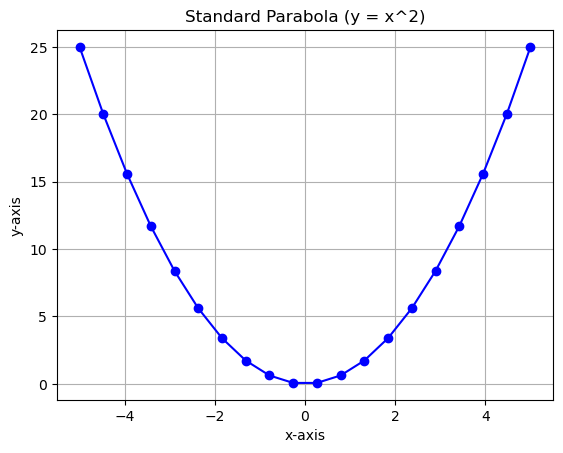

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Generate the initial data points as specified in the assignment
x = np.linspace(-5, 5, num=20)
y = np.array([j ** 2 for j in x])

# Plot the chart (using marker='o' to clearly visualize individual data points)
plt.plot(x, y, marker='o', linestyle='-', color='b')

# Add the required chart elements: title, axes labels, and grid
plt.title('Standard Parabola (y = x^2)')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.grid(True)

# Render the plot
plt.show()

What happens if the independent variable is not sorted before plotting? Try plotting directly using the following defined array.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
np.random.shuffle(x)
y = np.array([j ** 2 for j in x])
```

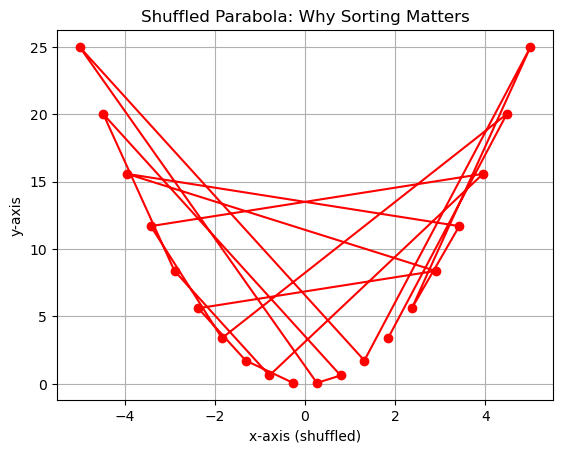

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Generate the initial array and shuffle the x-values as specified in the assignment
x = np.linspace(-5, 5, num=20)
np.random.shuffle(x)
y = np.array([j ** 2 for j in x])

# Plot the shuffled data (using a red line to distinguish it from the previous standard plot)
plt.plot(x, y, marker='o', linestyle='-', color='r')

# Add the required chart elements: title, axes labels, and grid
plt.title('Shuffled Parabola: Why Sorting Matters')
plt.xlabel('x-axis (shuffled)')
plt.ylabel('y-axis')
plt.grid(True)

# Render the plot
plt.show()

(b) Create multiple arrays and plot them with different styles, add legends, add text/mathematical equations on the plot.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])
```

copy the code above to the following cell and add code for plotting curve $\left(x, y1\right)$, $\left(x, y2\right)$ and $\left(x, y3\right)$.

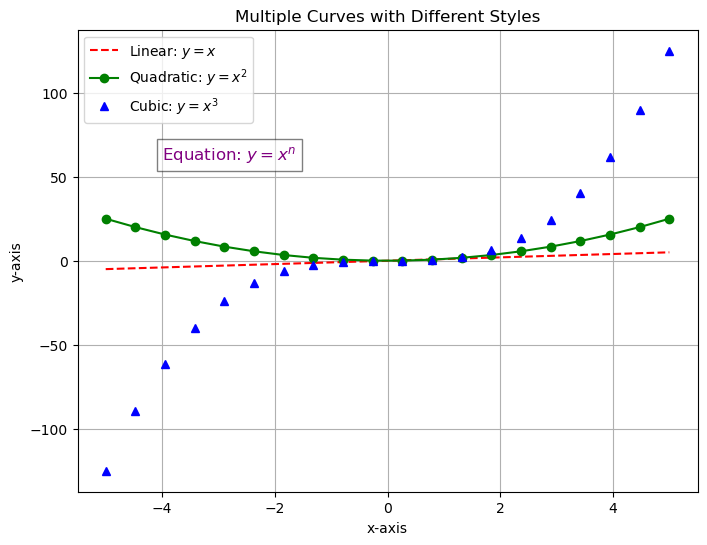

In [16]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])

plt.figure(figsize=(8, 6))

# Plot three curves using different styles (colors, line types, markers) and labels
plt.plot(x, y1, 'r--', label='Linear: $y=x$')      # Red dashed line
plt.plot(x, y2, 'g-o', label='Quadratic: $y=x^2$') # Green solid line with circle markers
plt.plot(x, y3, 'b^', label='Cubic: $y=x^3$')      # Blue triangles

# Add a legend and position it in the upper left corner
plt.legend(loc='upper left')
plt.title('Multiple Curves with Different Styles')
plt.xlabel('x-axis')
plt.ylabel('y-axis')

# Add mathematical text formatting (LaTeX supported) at a specific coordinate (x=-4, y=60)
plt.text(-4, 60, r'Equation: $y = x^n$', fontsize=12, color='purple', 
         bbox=dict(facecolor='white', alpha=0.5))

plt.grid(True)
plt.show()

(c) Create multiple arrays and plot them into one figure **(No multiple figure and no subplot is allowed in this question)**.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])
```

copy the code above to the following cell and add code for plotting curve $\left(x, y1\right)$, $\left(x, y2\right)$ and $\left(x, y3\right)$.

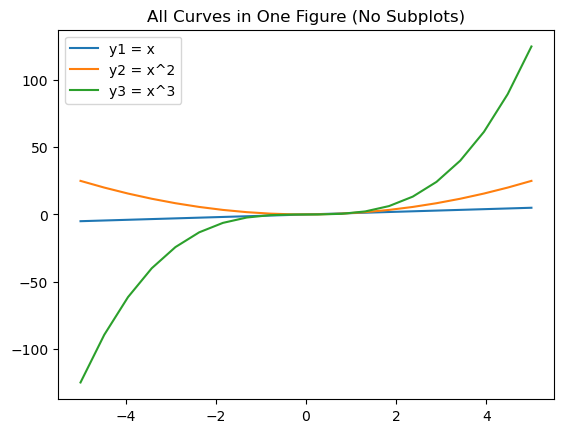

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])

# Plot all three curves together on a single set of axes
plt.plot(x, y1, label='y1 = x')
plt.plot(x, y2, label='y2 = x^2')
plt.plot(x, y3, label='y3 = x^3')

plt.title('All Curves in One Figure (No Subplots)')
plt.legend()
plt.show()

(d) Create multiple subplots, play around with the figure size, figure title, and its font style and font size **(One curve is plotted in one subplot in this question)**.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])
```

copy the code above to the following cell and add code for plotting curve $\left(x, y1\right)$, $\left(x, y2\right)$ and $\left(x, y3\right)$.

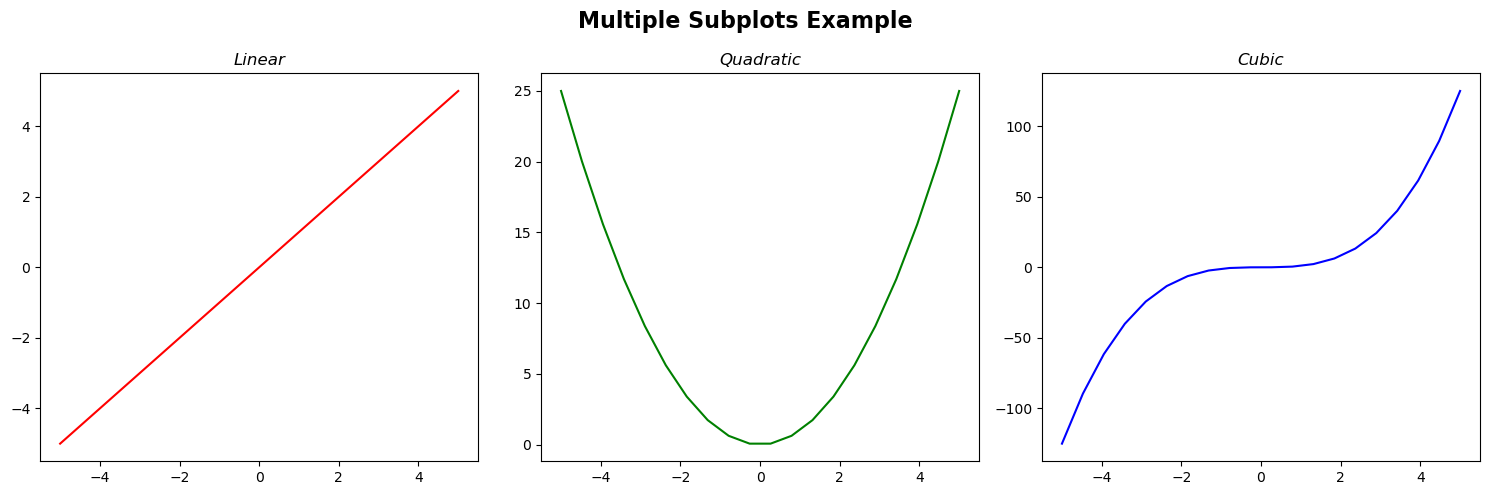

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])

# Create a 1x3 subplot grid with a figure size of 15x5
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Set the main title with specific font size, weight, and family
fig.suptitle('Multiple Subplots Example', fontsize=16, fontweight='bold', fontfamily='sans-serif')

# First subplot: Linear
axs[0].plot(x, y1, 'r')
axs[0].set_title('Linear', fontsize=12, fontstyle='italic')

# Second subplot: Quadratic
axs[1].plot(x, y2, 'g')
axs[1].set_title('Quadratic', fontsize=12, fontstyle='italic')

# Third subplot: Cubic
axs[2].plot(x, y3, 'b')
axs[2].set_title('Cubic', fontsize=12, fontstyle='italic')

# Automatically adjust subplot parameters to prevent overlapping text
plt.tight_layout()
plt.show()

(e) Change the limits on x and y axes, **use logarithmic axes to plot**.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y = np.array([j ** 2 for j in x])
```

copy the code above to the following cell and add code for plotting the parabola.

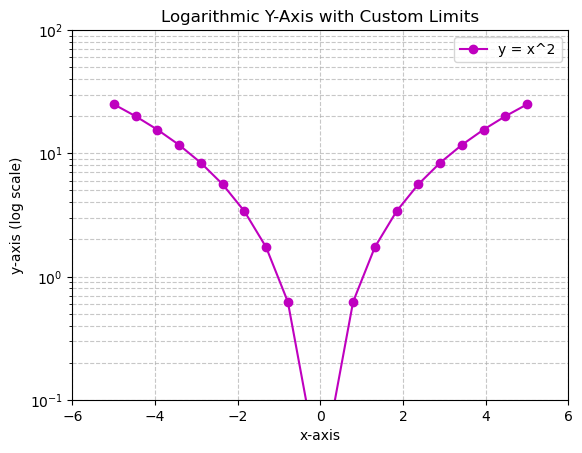

In [21]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, num=20)
y = np.array([j ** 2 for j in x])

# Plot the baseline chart
plt.plot(x, y, 'm-o', label='y = x^2')

# 1. Set Custom Axis Limits
plt.xlim(-6, 6)
plt.ylim(0.1, 100)

# 2. Apply a Logarithmic Scale to the Y-axis
plt.yscale('log')

# Add descriptive chart elements
plt.title('Logarithmic Y-Axis with Custom Limits')
plt.xlabel('x-axis')
plt.ylabel('y-axis (log scale)')
plt.legend()

# Enable the grid; using which="both" ensures that minor grid lines for the log scale are also displayed
plt.grid(True, which="both", linestyle='--', alpha=0.7)

plt.show()

### Pandas's DataFrame.plot and Seaborn

#### Pandas's DataFrame.plot

Use the Salaries.csv again (You can use the dataframe object loaded from section 3.1).

(a) For team 'ATL', plot a scatter plot between feature yearID and salary.

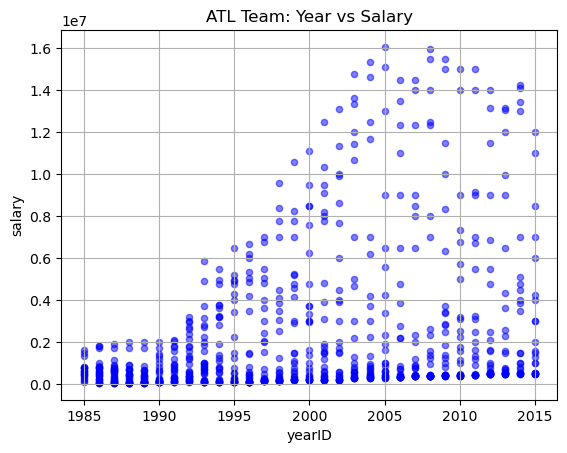

In [22]:
import matplotlib.pyplot as plt

# Filter the dataframe for the ATL team and use the built-in pandas scatter plot method
df_atl = df[df['teamID'] == 'ATL']
df_atl.plot.scatter(x='yearID', y='salary', title='ATL Team: Year vs Salary', color='blue', alpha=0.5)

plt.grid(True)
plt.show()

(b) For year 1985, plot a bar chart to show the average salary for each team.

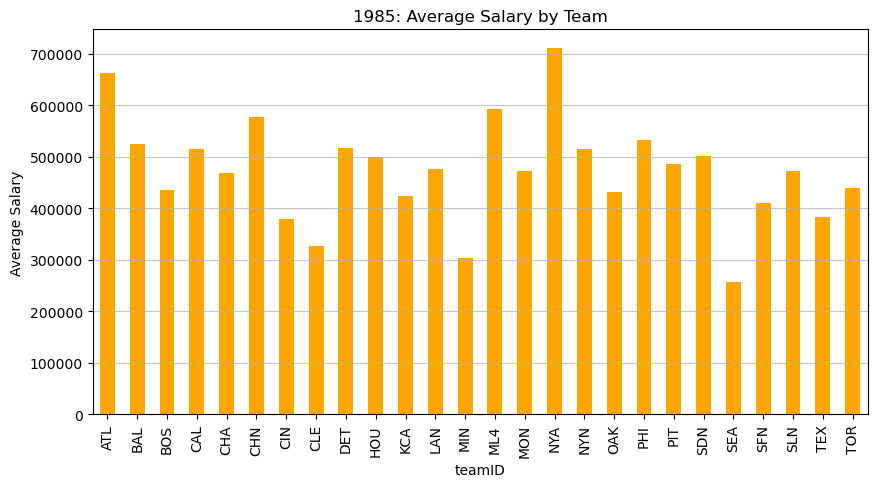

In [23]:
# Filter the dataframe for the year 1985, group by team, and calculate the mean salary
df_1985_mean = df[df['yearID'] == 1985].groupby('teamID')['salary'].mean()

# Plot the results as a bar chart
df_1985_mean.plot.bar(title='1985: Average Salary by Team', color='orange', figsize=(10, 5))

plt.ylabel('Average Salary')
plt.grid(axis='y', alpha=0.7) 
plt.show()

(c) For team 'ATL', plot a line chart to show how the annual average salary change by years.

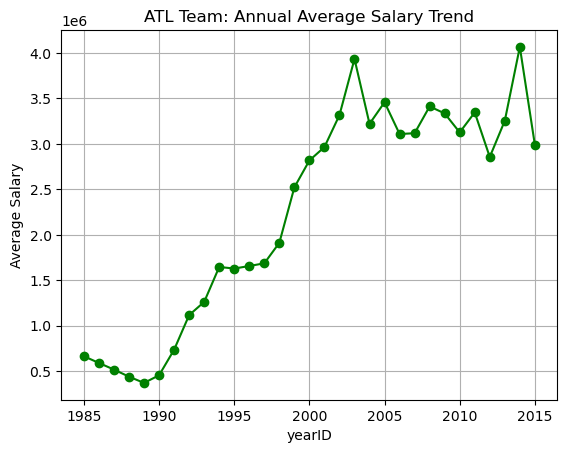

In [24]:
# Filter the dataframe for the ATL team, group by year, and compute the average salary
df_atl_mean_by_year = df[df['teamID'] == 'ATL'].groupby('yearID')['salary'].mean()

# Plot the results as a line chart
df_atl_mean_by_year.plot.line(title='ATL Team: Annual Average Salary Trend', marker='o', color='green')

plt.ylabel('Average Salary')
plt.grid(True)
plt.show()

#### Seaborn

(a) Append one more numeric feature to the data frame (can be generated randomly), then for team 'ATL', use the seaborn.pairplot to plot scatter plots among all numeric features in the data frame for team. 

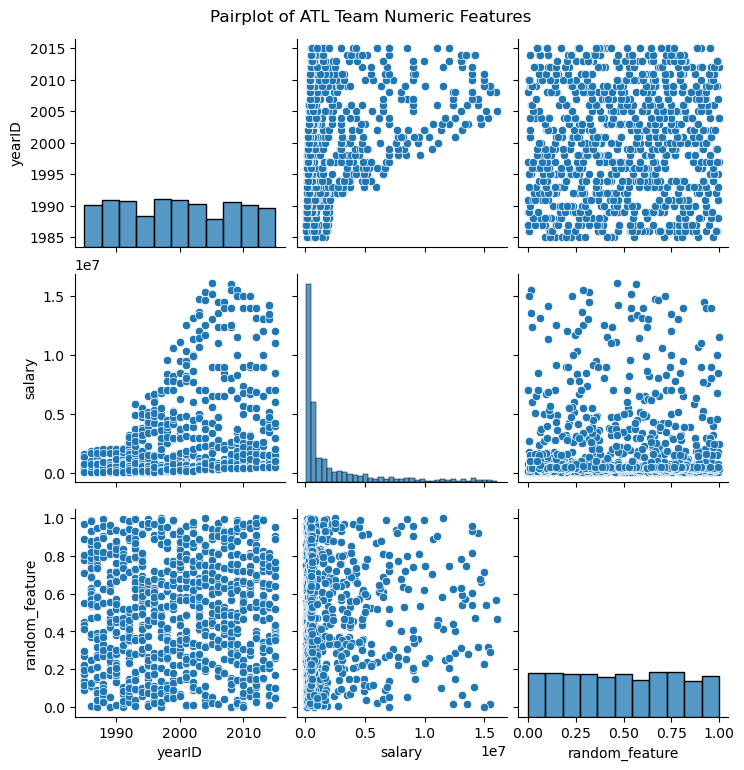

In [25]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Append a new column of random numerical values to the dataframe
df['random_feature'] = np.random.rand(len(df))

# 2. Filter for the ATL team and isolate specific numeric columns for the scatter plot matrix
df_atl_subset = df[df['teamID'] == 'ATL'][['yearID', 'salary', 'random_feature']]

# 3. Generate a Seaborn pairplot to visualize pairwise relationships
sns.pairplot(df_atl_subset)
plt.suptitle("Pairplot of ATL Team Numeric Features", y=1.02)
plt.show()

(b) For year 1985 and for each team, plot a boxplot to show how the salary distribute within a team.

/var/folders/lb/nks6wl5j62x6pcq6llh610tr0000gn/T/ipykernel_45332/3942796969.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='teamID', y='salary', data=df_1985, palette='Set3')


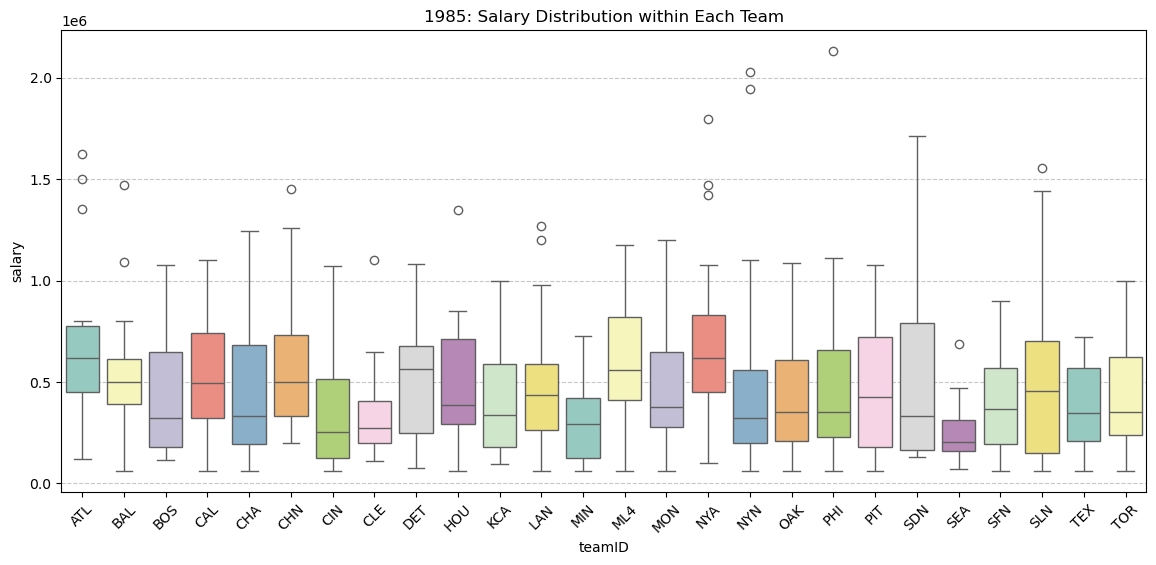

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the dataframe to isolate data from the year 1985
df_1985 = df[df['yearID'] == 1985]

# Set the figure size (expanding the width to prevent overlapping X-axis labels)
plt.figure(figsize=(14, 6))

# Generate a boxplot using seaborn to visualize the salary distribution per team
sns.boxplot(x='teamID', y='salary', data=df_1985, palette='Set3')

plt.title('1985: Salary Distribution within Each Team')
plt.xticks(rotation=45) # Rotate X-axis labels by 45 degrees to ensure readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

(c) Read the offical documentation (https://seaborn.pydata.org/) to understand how lmplot, catplot, relplot, and jointplot works.

### Jupyter Notebook

#### Jupyter Notebook Extensions

Extensions such as the code formatter, table of content is to make your development more efficient. To explore it, please refer to https://github.com/ipython-contrib/jupyter_contrib_nbextensions.

#### Jupyter Visual Debugger

The Pixie Debugger is a visual debugger for debugging on Jupyter Notebook. To explore it, please refer to https://medium.com/codait/the-visual-python-debugger-for-jupyter-notebooks-youve-always-wanted-761713babc62.

### Git and GitHub

1. In the directory that where this jupyter notebook file locates in, init a Git repository.
2. Checkout a new branch called dev and commit the current notebook within this branch.
3. Merge the dev branch to the master branch (the default branch).
4. Create a temporary repository (just for practicing and you can delete it later) in GitHub. 
5. Push new changes in the master branch to the remote repository created in step 4.
6. Checkout the dev branch again and do some changes to your notebook, and then repeat step 3 and step 5.